<a href="https://colab.research.google.com/github/shivanshi-09/weather_modelling/blob/main/ModifiedModifiedGraphCast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GraphCast



# Installation and Initialization


In [1]:
# @title Pip install graphcast and dependencies

%pip install --upgrade https://github.com/deepmind/graphcast/archive/master.zip

  Using cached https://github.com/deepmind/graphcast/archive/master.zip
  Preparing metadata (setup.py) ... done


In [2]:
# @title Workaround for cartopy crashes

# Workaround for cartopy crashes due to the shapely installed by default in
# google colab kernel (https://github.com/anitagraser/movingpandas/issues/81):
!pip uninstall -y shapely
!pip install shapely --no-binary shapely

Found existing installation: shapely 2.1.2
Uninstalling shapely-2.1.2:
  Successfully uninstalled shapely-2.1.2
  Using cached shapely-2.1.2-cp312-cp312-linux_x86_64.whl


In [3]:
# @title Imports

import dataclasses
import datetime
import functools
import math
import re
from typing import Optional

import cartopy.crs as ccrs
from google.cloud import storage
from graphcast import autoregressive
from graphcast import casting
from graphcast import checkpoint
from graphcast import data_utils
from graphcast import graphcast
from graphcast import normalization
from graphcast import rollout
from graphcast import xarray_jax
from graphcast import xarray_tree
from IPython.display import HTML
import ipywidgets as widgets
import haiku as hk
import jax
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
import xarray as xr


def parse_file_parts(file_name):
  return dict(part.split("-", 1) for part in file_name.split("_"))


In [4]:
# @title Authenticate with Google Cloud Storage

gcs_client = storage.Client.create_anonymous_client()
gcs_bucket = gcs_client.get_bucket("dm_graphcast")
dir_prefix = "graphcast/"

In [5]:
import google.auth
import google.auth.transport.requests

creds, _ = google.auth.default(
    scopes=['https://www.googleapis.com/auth/devstorage.read_only']
)
creds.refresh(google.auth.transport.requests.Request())

token_dict = {
    "token": creds.token,
    "refresh_token": creds.refresh_token,
    "token_uri": creds.token_uri,
    "client_id": creds.client_id,
    "client_secret": creds.client_secret,
}

import gcsfs, xarray as xr
fs = gcsfs.GCSFileSystem(token=token_dict)
store_wb = fs.get_mapper('gs://gcp-public-data-arco-era5/ar/1959-2022-wb13-6h-0p25deg-chunk-1.zarr-v2')
era5_wb = xr.open_zarr(store_wb, consolidated=False, chunks='auto')
print("ERA5 loaded:", list(era5_wb.data_vars))

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


ERA5 loaded: ['10m_u_component_of_wind', '10m_v_component_of_wind', 'lake_depth', 'geopotential_at_surface', '2m_temperature', 'land_sea_mask', 'angle_of_sub_gridscale_orography', 'anisotropy_of_sub_gridscale_orography', 'high_vegetation_cover', 'lake_cover', 'geopotential', 'low_vegetation_cover', 'mean_sea_level_pressure', 'slope_of_sub_gridscale_orography', 'sea_surface_temperature', 'soil_type', 'standard_deviation_of_filtered_subgrid_orography', 'standard_deviation_of_orography', 'sea_ice_cover', 'surface_pressure', 'specific_humidity', 'toa_incident_solar_radiation_12hr', 'toa_incident_solar_radiation_24hr', 'temperature', 'toa_incident_solar_radiation', 'toa_incident_solar_radiation_6hr', 'total_cloud_cover', 'total_column_water_vapour', 'total_precipitation_12hr', 'total_precipitation_24hr', 'type_of_high_vegetation', 'u_component_of_wind', 'total_precipitation_6hr', 'vertical_velocity', 'v_component_of_wind', 'type_of_low_vegetation']


In [6]:
# @title Plotting functions

def select(
    data: xr.Dataset,
    variable: str,
    level: Optional[int] = None,
    max_steps: Optional[int] = None
    ) -> xr.Dataset:
  data = data[variable]
  if "batch" in data.dims:
    data = data.isel(batch=0)
  if max_steps is not None and "time" in data.sizes and max_steps < data.sizes["time"]:
    data = data.isel(time=range(0, max_steps))
  if level is not None and "level" in data.coords:
    data = data.sel(level=level)
  return data

def scale(
    data: xr.Dataset,
    center: Optional[float] = None,
    robust: bool = False,
    ) -> tuple[xr.Dataset, matplotlib.colors.Normalize, str]:
  vmin = np.nanpercentile(data, (2 if robust else 0))
  vmax = np.nanpercentile(data, (98 if robust else 100))
  if center is not None:
    diff = max(vmax - center, center - vmin)
    vmin = center - diff
    vmax = center + diff
  return (data, matplotlib.colors.Normalize(vmin, vmax),
          ("RdBu_r" if center is not None else "viridis"))

def plot_data(
    data: dict[str, xr.Dataset],
    fig_title: str,
    plot_size: float = 5,
    robust: bool = False,
    cols: int = 4
    ) -> tuple[xr.Dataset, matplotlib.colors.Normalize, str]:

  first_data = next(iter(data.values()))[0]
  max_steps = first_data.sizes.get("time", 1)
  assert all(max_steps == d.sizes.get("time", 1) for d, _, _ in data.values())

  cols = min(cols, len(data))
  rows = math.ceil(len(data) / cols)
  figure = plt.figure(figsize=(plot_size * 2 * cols,
                               plot_size * rows))
  figure.suptitle(fig_title, fontsize=16)
  figure.subplots_adjust(wspace=0, hspace=0)
  figure.tight_layout()

  images = []
  for i, (title, (plot_data, norm, cmap)) in enumerate(data.items()):
    ax = figure.add_subplot(rows, cols, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    im = ax.imshow(
        plot_data.isel(time=0, missing_dims="ignore"), norm=norm,
        origin="lower", cmap=cmap)
    plt.colorbar(
        mappable=im,
        ax=ax,
        orientation="vertical",
        pad=0.02,
        aspect=16,
        shrink=0.75,
        cmap=cmap,
        extend=("both" if robust else "neither"))
    images.append(im)

  def update(frame):
    if "time" in first_data.dims:
      td = datetime.timedelta(microseconds=first_data["time"][frame].item() / 1000)
      figure.suptitle(f"{fig_title}, {td}", fontsize=16)
    else:
      figure.suptitle(fig_title, fontsize=16)
    for im, (plot_data, norm, cmap) in zip(images, data.values()):
      im.set_data(plot_data.isel(time=frame, missing_dims="ignore"))

  ani = animation.FuncAnimation(
      fig=figure, func=update, frames=max_steps, interval=250)
  plt.close(figure.number)
  return HTML(ani.to_jshtml())

# Load the Data and initialize the model

## Load the model params

In [7]:
# @title Choose the model

params_file_options = [
    name for blob in gcs_bucket.list_blobs(prefix=dir_prefix+"params/")
    if (name := blob.name.removeprefix(dir_prefix+"params/"))]  # Drop empty string.

random_mesh_size = widgets.IntSlider(
    value=4, min=4, max=6, description="Mesh size:")
random_gnn_msg_steps = widgets.IntSlider(
    value=4, min=1, max=32, description="GNN message steps:")
random_latent_size = widgets.Dropdown(
    options=[int(2**i) for i in range(4, 10)], value=32,description="Latent size:")
random_levels = widgets.Dropdown(
    options=[13, 37], value=13, description="Pressure levels:")


params_file = widgets.Dropdown(
    options=params_file_options,
    description="Params file:",
    layout={"width": "max-content"})

source_tab = widgets.Tab([
    widgets.VBox([
        random_mesh_size,
        random_gnn_msg_steps,
        random_latent_size,
        random_levels,
    ]),
    params_file,
])
source_tab.set_title(0, "Random")
source_tab.set_title(1, "Checkpoint")
widgets.VBox([
    source_tab,
    widgets.Label(value="Run the next cell to load the model. Rerunning this cell clears your selection.")
])


In [8]:
# @title Load the model

source = source_tab.get_title(source_tab.selected_index)

if source == "Random":
  params = None
  state = {}
  model_config = graphcast.ModelConfig(
      resolution=0,
      mesh_size=random_mesh_size.value,
      latent_size=random_latent_size.value,
      gnn_msg_steps=random_gnn_msg_steps.value,
      hidden_layers=1,
      radius_query_fraction_edge_length=0.6)
  task_config = graphcast.TaskConfig(
      input_variables=graphcast.TASK.input_variables,
      target_variables=graphcast.TASK.target_variables,
      forcing_variables=graphcast.TASK.forcing_variables,
      pressure_levels=graphcast.PRESSURE_LEVELS[random_levels.value],
      input_duration=graphcast.TASK.input_duration,
  )
else:
  assert source == "Checkpoint"
  with gcs_bucket.blob(f"{dir_prefix}params/{params_file.value}").open("rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)
  params = ckpt.params
  state = {}

  model_config = ckpt.model_config
  task_config = ckpt.task_config
  print("Model description:\n", ckpt.description, "\n")
  print("Model license:\n", ckpt.license, "\n")

model_config

ModelConfig(resolution=0, mesh_size=4, latent_size=32, gnn_msg_steps=4, hidden_layers=1, radius_query_fraction_edge_length=0.6, mesh2grid_edge_normalization_factor=None)

## Load the example data


In [9]:
# @title Get and filter the list of available example datasets

dataset_file_options = [
    name for blob in gcs_bucket.list_blobs(prefix=dir_prefix+"dataset/")
    if (name := blob.name.removeprefix(dir_prefix+"dataset/"))]  # Drop empty string.

def data_valid_for_model(
    file_name: str, model_config: graphcast.ModelConfig, task_config: graphcast.TaskConfig):
  file_parts = parse_file_parts(file_name.removesuffix(".nc"))
  return (
      model_config.resolution in (0, float(file_parts["res"])) and
      len(task_config.pressure_levels) == int(file_parts["levels"]) and
      (
          ("total_precipitation_6hr" in task_config.input_variables and
           file_parts["source"] in ("era5", "fake")) or
          ("total_precipitation_6hr" not in task_config.input_variables and
           file_parts["source"] in ("hres", "fake"))
      )
  )


dataset_file = widgets.Dropdown(
    options=[
        (", ".join([f"{k}: {v}" for k, v in parse_file_parts(option.removesuffix(".nc")).items()]), option)
        for option in dataset_file_options
        if data_valid_for_model(option, model_config, task_config)
    ],
    description="Dataset file:",
    layout={"width": "max-content"})
widgets.VBox([
    dataset_file,
    widgets.Label(value="Run the next cell to load the dataset. Rerunning this cell clears your selection and refilters the datasets that match your model.")
])

In [29]:
VARIABLES = [
    # Atmospheric (pressure levels)
    'u_component_of_wind',
    'v_component_of_wind',
    'temperature',
    'specific_humidity',
    'geopotential',
    'vertical_velocity',
    # Surface
    '2m_temperature',
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    'mean_sea_level_pressure',
    'toa_incident_solar_radiation',
    'total_precipitation_6hr',
]
LAT = slice(35, 5)
LON = slice(65, 100)

# Amphan landfall: May 20
# → t0 = May 19 12:00, t1 = May 19 18:00, predicts May 20 onwards
amphan = era5_wb[VARIABLES].sel(time=slice('2020-05-19', '2020-05-21'), latitude=LAT, longitude=LON)

# Fani landfall: May 3
# → t0 = May 2 12:00, t1 = May 2 18:00, predicts May 3 onwards
fani = era5_wb[VARIABLES].sel(time=slice('2019-05-02', '2019-05-04'), latitude=LAT, longitude=LON)

# Kerala floods peak: Aug 15
# → t0 = Aug 14 12:00, t1 = Aug 14 18:00, predicts Aug 15 onwards
kerala = era5_wb[VARIABLES].sel(time=slice('2018-08-14', '2018-08-17'), latitude=LAT, longitude=LON)

print("Loading Amphan...")
amphan_loaded = amphan.compute()
print("Done!", amphan_loaded.dims)

print("Loading Fani...")
fani_loaded = fani.compute()
print("Done!", fani_loaded.dims)

print("Loading Kerala...")
kerala_loaded = kerala.compute()
print("Done!", kerala_loaded.dims)

Loading Amphan...
Done! FrozenMappingWarningOnValuesAccess({'time': 12, 'level': 13, 'latitude': 121, 'longitude': 141})
Loading Fani...
Done! FrozenMappingWarningOnValuesAccess({'time': 12, 'level': 13, 'latitude': 121, 'longitude': 141})
Loading Kerala...
Done! FrozenMappingWarningOnValuesAccess({'time': 16, 'level': 13, 'latitude': 121, 'longitude': 141})


In [30]:
def prepare_graphcast_input(ds, event_name):
    """
    Format ERA5 data into GraphCast input format.
    GraphCast needs 2 consecutive timesteps as input to predict the next one.
    """
    PRESSURE_LEVELS = [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100,
                       125, 150, 175, 200, 225, 250, 300, 350, 400,
                       450, 500, 550, 600, 650, 700, 750, 775, 800,
                       825, 850, 875, 900, 925, 950, 975, 1000]

    ds_renamed = ds.rename({
        'u_component_of_wind': 'u_wind',
        'v_component_of_wind': 'v_wind' if 'v_component_of_wind' in ds else None,
        '10m_u_component_of_wind': 'u10',
        '10m_v_component_of_wind': 'v10',
        '2m_temperature': 't2m',
        #'surface_pressure': 'sp',
        'temperature': 't',
        'specific_humidity': 'q',
        'geopotential': 'z',
        'vertical_velocity': 'w',
    })
    ds_renamed = ds_renamed[[v for v in ds_renamed.data_vars if v is not None]]

    t0 = ds_renamed.isel(time=0)
    t1 = ds_renamed.isel(time=1)

    print(f"\n{event_name} GraphCast input ready:")
    print(f"Timestep 0: {ds.time.values[0]}")
    print(f"Timestep 1: {ds.time.values[1]}")
    print(f"Forecast target starts: {ds.time.values[2]}")
    print(f"Grid: {len(ds.latitude)} lat x {len(ds.longitude)} lon")
    print(f"Levels: {len(ds.level)}")

    return t0, t1, ds_renamed

amphan_t0, amphan_t1, amphan_ds = prepare_graphcast_input(amphan_loaded, "Cyclone Amphan")
fani_t0, fani_t1, fani_ds = prepare_graphcast_input(fani_loaded, "Cyclone Fani")
kerala_t0, kerala_t1, kerala_ds = prepare_graphcast_input(kerala_loaded, "Kerala Floods")


Cyclone Amphan GraphCast input ready:
  Timestep 0: 2020-05-19T00:00:00.000000000
  Timestep 1: 2020-05-19T06:00:00.000000000
  Forecast target starts: 2020-05-19T12:00:00.000000000
  Grid: 121 lat x 141 lon
  Levels: 13

Cyclone Fani GraphCast input ready:
  Timestep 0: 2019-05-02T00:00:00.000000000
  Timestep 1: 2019-05-02T06:00:00.000000000
  Forecast target starts: 2019-05-02T12:00:00.000000000
  Grid: 121 lat x 141 lon
  Levels: 13

Kerala Floods GraphCast input ready:
  Timestep 0: 2018-08-14T00:00:00.000000000
  Timestep 1: 2018-08-14T06:00:00.000000000
  Forecast target starts: 2018-08-14T12:00:00.000000000
  Grid: 121 lat x 141 lon
  Levels: 13


In [31]:
# @title Format our ERA5 event data as example_batch for GraphCast
def format_as_example_batch(ds, static_vars):
    ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
    ds = ds.expand_dims('batch', axis=1)
    pressure_levels = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
    ds = ds.assign_coords(level=pressure_levels)

    # Add datetime coordinate (batch, time)
    datetimes = ds.time.values
    datetime_coord = np.array([datetimes])  # shape (1, time)
    ds = ds.assign_coords(datetime=(('batch', 'time'), datetime_coord))

    # Add static variables (no time dimension)
    for var in static_vars:
        if var in era5_wb:
            static = era5_wb[var]
            # Drop time dim if it exists
            if 'time' in static.dims:
                static = static.isel(time=0)
            static = static.rename({'latitude': 'lat', 'longitude': 'lon'})
            static = static.sel(lat=ds.lat, lon=ds.lon)
            static = static.expand_dims('batch', axis=0)
            ds[var] = static

    return ds

STATIC_VARS = ['geopotential_at_surface', 'land_sea_mask']

event_data = amphan_loaded
event_name = "Cyclone Amphan 2020"

example_batch = format_as_example_batch(event_data, STATIC_VARS)

print(f"Running GraphCast for: {event_name}")
print("Coords:", list(example_batch.coords))
print("Variables:", list(example_batch.data_vars))

Running GraphCast for: Cyclone Amphan 2020
Coords: ['lat', 'lon', 'time', 'level', 'datetime']
Variables: ['u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'geopotential', 'vertical_velocity', '2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure', 'toa_incident_solar_radiation', 'total_precipitation_6hr', 'geopotential_at_surface', 'land_sea_mask']


In [32]:
# @title Choose training and eval data to extract
train_steps = widgets.IntSlider(
    value=1, min=1, max=example_batch.sizes["time"]-2, description="Train steps")

# Clamp eval_steps max so autoregressor doesn't run out of data
max_eval = min(5, example_batch.sizes["time"]-2)  # cap at 5 but stay safe
eval_steps = widgets.IntSlider(
    value=max_eval, min=1, max=max_eval, description="Eval steps")

widgets.VBox([
    train_steps,
    eval_steps,
    widgets.Label(value="Run the next cell to extract the data. Rerunning this cell clears your selection.")
])


In [33]:
# @title Extract training and eval data

train_inputs, train_targets, train_forcings = data_utils.extract_inputs_targets_forcings(
    example_batch, target_lead_times=slice("6h", f"{train_steps.value*6}h"),
    **dataclasses.asdict(task_config))

eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    example_batch, target_lead_times=slice("6h", f"{eval_steps.value*6}h"),
    **dataclasses.asdict(task_config))

print("All Examples:", example_batch.dims.mapping)
print("Train Inputs:", train_inputs.dims.mapping)
print("Train Targets:", train_targets.dims.mapping)
print("Train Forcings:", train_forcings.dims.mapping)
print("Eval Inputs:", eval_inputs.dims.mapping)
print("Eval Targets:", eval_targets.dims.mapping)
print("Eval Forcings:", eval_forcings.dims.mapping)


All Examples:   {'time': 12, 'batch': 1, 'level': 13, 'lat': 121, 'lon': 141}
Train Inputs:   {'time': 2, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Train Targets:  {'time': 1, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Train Forcings: {'time': 1, 'batch': 1, 'lat': 121, 'lon': 141}
Eval Inputs:    {'time': 2, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Eval Targets:   {'time': 5, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Eval Forcings:  {'time': 5, 'batch': 1, 'lat': 121, 'lon': 141}


In [34]:
# @title Load normalization data

with gcs_bucket.blob(dir_prefix+"stats/diffs_stddev_by_level.nc").open("rb") as f:
  diffs_stddev_by_level = xr.load_dataset(f).compute()
with gcs_bucket.blob(dir_prefix+"stats/mean_by_level.nc").open("rb") as f:
  mean_by_level = xr.load_dataset(f).compute()
with gcs_bucket.blob(dir_prefix+"stats/stddev_by_level.nc").open("rb") as f:
  stddev_by_level = xr.load_dataset(f).compute()

In [35]:
# @title Convert dask arrays to numpy for JAX

train_inputs = train_inputs.compute()
train_targets= train_targets.compute()
train_forcings= train_forcings.compute()
eval_inputs = eval_inputs.compute()
eval_targets = eval_targets.compute()
eval_forcings = eval_forcings.compute()

print("All datasets computed for JAX")
print("Train Inputs:  ", train_inputs.dims.mapping)
print("Train Targets: ", train_targets.dims.mapping)
print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)

All datasets computed for JAX
Train Inputs:   {'time': 2, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Train Targets:  {'time': 1, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Eval Inputs:    {'time': 2, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Eval Targets:   {'time': 5, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}


In [36]:
# @title Build jitted functions, and possibly initialize random weights

def construct_wrapped_graphcast(
    model_config: graphcast.ModelConfig,
    task_config: graphcast.TaskConfig):
  """Constructs and wraps the GraphCast Predictor."""
  # Deeper one-step predictor.
  predictor = graphcast.GraphCast(model_config, task_config)

  # Modify inputs/outputs to `graphcast.GraphCast` to handle conversion to
  # from/to float32 to/from BFloat16.
  predictor = casting.Bfloat16Cast(predictor)

  # Modify inputs/outputs to `casting.Bfloat16Cast` so the casting to/from
  # BFloat16 happens after applying normalization to the inputs/targets.
  predictor = normalization.InputsAndResiduals(
      predictor,
      diffs_stddev_by_level=diffs_stddev_by_level,
      mean_by_level=mean_by_level,
      stddev_by_level=stddev_by_level)

  # Wraps everything so the one-step model can produce trajectories.
  predictor = autoregressive.Predictor(predictor, gradient_checkpointing=True)
  return predictor


@hk.transform_with_state
def run_forward(model_config, task_config, inputs, targets_template, forcings):
  predictor = construct_wrapped_graphcast(model_config, task_config)
  return predictor(inputs, targets_template=targets_template, forcings=forcings)


@hk.transform_with_state
def loss_fn(model_config, task_config, inputs, targets, forcings):
  predictor = construct_wrapped_graphcast(model_config, task_config)
  loss, diagnostics = predictor.loss(inputs, targets, forcings)
  return xarray_tree.map_structure(
      lambda x: xarray_jax.unwrap_data(x.mean(), require_jax=True),
      (loss, diagnostics))

def grads_fn(params, state, model_config, task_config, inputs, targets, forcings):
  def _aux(params, state, i, t, f):
    (loss, diagnostics), next_state = loss_fn.apply(
        params, state, jax.random.PRNGKey(0), model_config, task_config,
        i, t, f)
    return loss, (diagnostics, next_state)
  (loss, (diagnostics, next_state)), grads = jax.value_and_grad(
      _aux, has_aux=True)(params, state, inputs, targets, forcings)
  return loss, diagnostics, next_state, grads

# Jax doesn't seem to like passing configs as args through the jit. Passing it
# in via partial (instead of capture by closure) forces jax to invalidate the
# jit cache if you change configs.
def with_configs(fn):
  return functools.partial(
      fn, model_config=model_config, task_config=task_config)

# Always pass params and state, so the usage below are simpler
def with_params(fn):
  return functools.partial(fn, params=params, state=state)

# Our models aren't stateful, so the state is always empty, so just return the
# predictions. This is requiredy by our rollout code, and generally simpler.
def drop_state(fn):
  return lambda **kw: fn(**kw)[0]

init_jitted = jax.jit(with_configs(run_forward.init))

if params is None:
  params, state = init_jitted(
      rng=jax.random.PRNGKey(0),
      inputs=train_inputs,
      targets_template=train_targets,
      forcings=train_forcings)

loss_fn_jitted = drop_state(with_params(jax.jit(with_configs(loss_fn.apply))))
grads_fn_jitted = with_params(jax.jit(with_configs(grads_fn)))
run_forward_jitted = drop_state(with_params(jax.jit(with_configs(
    run_forward.apply))))

# Run the model

Note that the cell below may take a while (possibly minutes) to run the first time you execute them, because this will include the time it takes for the code to compile. The second time running will be significantly faster.

This use the python loop to iterate over prediction steps, where the 1-step prediction is jitted. This has lower memory requirements than the training steps below, and should enable making prediction with the small GraphCast model on 1 deg resolution data for 4 steps.

In [37]:
# @title Autoregressive rollout (loop in python)

assert model_config.resolution in (0, 360. / eval_inputs.sizes["lon"]), (
  "Model resolution doesn't match the data resolution. You likely want to "
  "re-filter the dataset list, and download the correct data.")

print("Inputs:", eval_inputs.dims.mapping)
print("Targets:", eval_targets.dims.mapping)
print("Forcings:", eval_forcings.dims.mapping)

predictions = rollout.chunked_prediction(
    run_forward_jitted,
    rng=jax.random.PRNGKey(0),
    inputs=eval_inputs,
    targets_template=eval_targets * np.nan,
    forcings=eval_forcings)
predictions

Inputs:   {'time': 2, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Targets:  {'time': 5, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13}
Forcings: {'time': 5, 'batch': 1, 'lat': 121, 'lon': 141}


/usr/local/lib/python3.12/dist-packages/graphcast/rollout.py:327: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/usr/local/lib/python3.12/dist-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/usr/local/lib/python3.12/dist-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension

<xarray.Dataset> Size: 28MB
Dimensions:                  (time: 5, batch: 1, lat: 121, lon: 141, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 40B 06:00:00 ... 1 days 0...
  * lat                      (lat) float32 484B 35.0 34.75 34.5 ... 5.5 5.25 5.0
  * lon                      (lon) float32 564B 65.0 65.25 65.5 ... 99.75 100.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 341kB 0.9952 ......
    10m_v_component_of_wind  (time, batch, lat, lon) float32 341kB -6.881 ......
    2m_temperature           (time, batch, lat, lon) float32 341kB 288.0 ... ...
    geopotential             (time, batch, level, lat, lon) float32 4MB 2.034...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 341kB 1.013e+05 ...
    specific_humidity        (time, batch, level, lat, lon) float32 4MB 2.89e...
    temperature              (time, batch, level, lat, lon) float32 4MB 213.6...
    total_precipitation_6hr  (time, batch, lat, lon) float32 341kB -0.0008797...
    u_component_of_wind      (time, batch, level, lat, lon) float32 4MB 3.372...
    v_component_of_wind      (time, batch, level, lat, lon) float32 4MB 8.133...
    vertical_velocity        (time, batch, level, lat, lon) float32 4MB 0.006...


Processing Cyclone Amphan 2020...
 Loaded dims: {'time': 12, 'level': 13, 'latitude': 121, 'longitude': 141}
 Time range: 2020-05-19T00:00:00.000000000 → 2020-05-21T18:00:00.000000000
 Input timesteps: 2020-05-19T00:00:00.000000000 and 2020-05-19T06:00:00.000000000
 Forecast steps: 2020-05-19T12:00:00.000000000 → 2020-05-21T18:00:00.000000000


/usr/local/lib/python3.12/dist-packages/graphcast/rollout.py:327: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/usr/local/lib/python3.12/dist-packages/graphcast/rollout.py:434: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_inputs = prev_inputs.dims["time"]
/usr/local/lib/python3.12/dist-packages/graphcast/rollout.py:436: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both data_vars='differ


Processing Cyclone Fani 2019...
 Loaded dims: {'time': 12, 'level': 13, 'latitude': 121, 'longitude': 141}
 Time range: 2019-05-02T00:00:00.000000000 → 2019-05-04T18:00:00.000000000
 Input timesteps: 2019-05-02T00:00:00.000000000 and 2019-05-02T06:00:00.000000000
 Forecast steps: 2019-05-02T12:00:00.000000000 → 2019-05-04T18:00:00.000000000

Processing Kerala Floods 2018...
 Loaded dims: {'time': 16, 'level': 13, 'latitude': 121, 'longitude': 141}
 Time range: 2018-08-14T00:00:00.000000000 → 2018-08-17T18:00:00.000000000
 Input timesteps: 2018-08-14T00:00:00.000000000 and 2018-08-14T06:00:00.000000000
 Forecast steps: 2018-08-14T12:00:00.000000000 → 2018-08-17T18:00:00.000000000


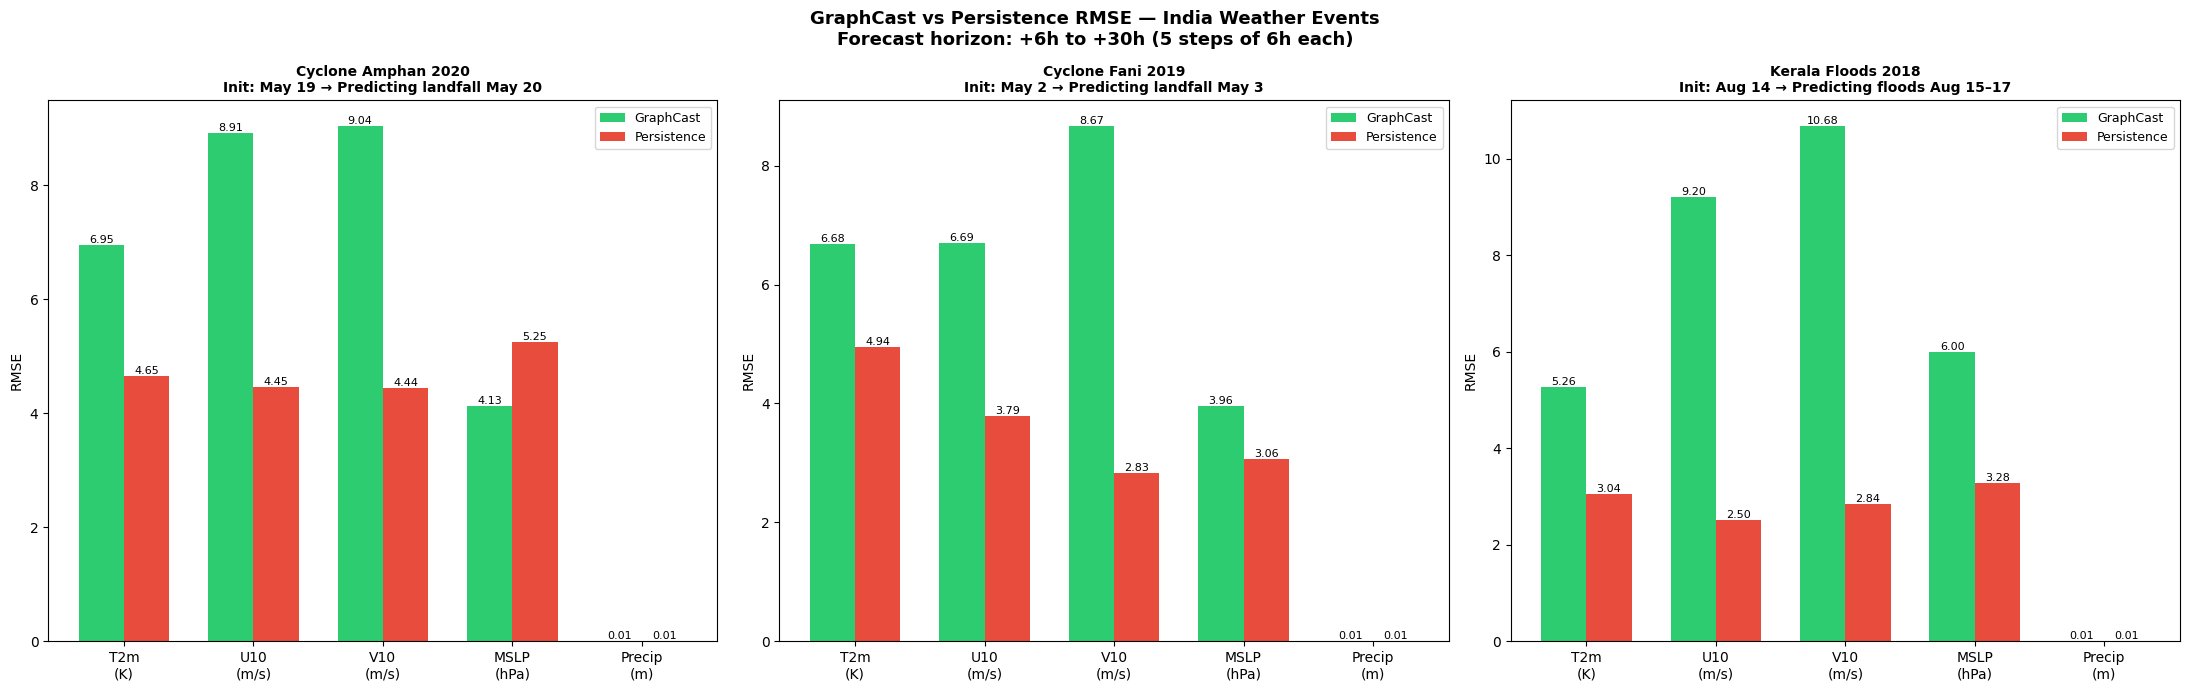

In [39]:
event_init_times = {
    "Cyclone Amphan 2020": "Init: May 19 → Predicting landfall May 20",
    "Cyclone Fani 2019": "Init: May 2 → Predicting landfall May 3",
    "Kerala Floods 2018": "Init: Aug 14 → Predicting floods Aug 15–17",
}

def compute_rmse_xarray(pred, truth, var):
    err = pred[var].values - truth[var].values
    return np.sqrt(np.mean(err**2))

surface_vars = [
    '2m_temperature',
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    'mean_sea_level_pressure',
    'total_precipitation_6hr',
]

results = {}

for event_name, event_data in [
    ("Cyclone Amphan 2020", amphan_loaded),
    ("Cyclone Fani 2019", fani_loaded),
    ("Kerala Floods 2018", kerala_loaded),
]:
    print(f"\nProcessing {event_name}...")
    print(f"Loaded dims: {event_data.dims.mapping}")
    print(f"Time range: {event_data.time.values[0]} → {event_data.time.values[-1]}")
    print(f"Input timesteps: {event_data.time.values[0]} and {event_data.time.values[1]}")
    print(f"Forecast steps: {event_data.time.values[2]} → {event_data.time.values[-1]}")

    example_batch = format_as_example_batch(event_data, STATIC_VARS)

    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
        example_batch, target_lead_times=slice("6h", f"{eval_steps.value*6}h"),
        **dataclasses.asdict(task_config))

    eval_inputs = eval_inputs.compute()
    eval_targets = eval_targets.compute()
    eval_forcings = eval_forcings.compute()

    gc_predictions = rollout.chunked_prediction(
        run_forward_jitted,
        rng=jax.random.PRNGKey(0),
        inputs=eval_inputs,
        targets_template=eval_targets * np.nan,
        forcings=eval_forcings)

    n_steps = eval_targets.sizes['time']
    last_state = example_batch.isel(time=1)
    pers_pred = xr.concat([last_state] * n_steps, dim='time').assign_coords(
        time=example_batch.time.values[2:2+n_steps])

    gc_rmse, pers_rmse = {}, {}
    for var in surface_vars:
        if var in gc_predictions and var in eval_targets:
            gc_rmse[var]   = compute_rmse_xarray(gc_predictions, eval_targets, var)
            pers_rmse[var] = compute_rmse_xarray(pers_pred,      eval_targets, var)

    results[event_name] = {'graphcast': gc_rmse, 'persistence': pers_rmse}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
short_names = ['T2m\n(K)', 'U10\n(m/s)', 'V10\n(m/s)', 'MSLP\n(hPa)', 'Precip\n(m)']
x = np.arange(len(surface_vars))
width = 0.35

for ax, (event_name, res) in zip(axes, results.items()):
    gc_vals   = [res['graphcast'].get(v, 0)   for v in surface_vars]
    pers_vals = [res['persistence'].get(v, 0) for v in surface_vars]

    idx_mslp = surface_vars.index('mean_sea_level_pressure')
    gc_vals[idx_mslp]/= 100
    pers_vals[idx_mslp]/= 100

    bars1 = ax.bar(x - width/2, gc_vals,   width, label='GraphCast',  color='#2ecc71')
    bars2 = ax.bar(x + width/2, pers_vals, width, label='Persistence', color='#e74c3c')

    subtitle = event_init_times[event_name]
    ax.set_title(f"{event_name}\n{subtitle}", fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names)
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=9)

    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'GraphCast vs Persistence RMSE — India Weather Events\n'
    'Forecast horizon: +6h to +30h (5 steps of 6h each)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('graphcast_vs_persistence_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
india = predictions.sel(
    lat = slice(5, 35),
    lon = slice(65, 100)
)
print(india)

<xarray.Dataset> Size: 708B
Dimensions:                  (time: 5, batch: 1, lat: 0, lon: 141, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 40B 06:00:00 ... 1 days 0...
  * lat                      (lat) float32 0B 
  * lon                      (lon) float32 564B 65.0 65.25 65.5 ... 99.75 100.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 0B 
    10m_v_component_of_wind  (time, batch, lat, lon) float32 0B 
    2m_temperature           (time, batch, lat, lon) float32 0B 
    geopotential             (time, batch, level, lat, lon) float32 0B 
    mean_sea_level_pressure  (time, batch, lat, lon) float32 0B 
    specific_humidity        (time, batch, level, lat, lon) float32 0B 
    temperature              (time, batch, level, lat, lon) float32 0B 
    total_precipitation_6hr  (time, batch, lat, lon) float32 0B

In [21]:
temp = india["2m_temperature"] - 273.15
u_wind = india["10m_u_component_of_wind"]
v_wind = india["10m_v_component_of_wind"]
wind_speed = np.sqrt(u_wind**2 + v_wind**2)
print(temp, u_wind, v_wind)

<xarray.DataArray '2m_temperature' (time: 5, batch: 1, lat: 0, lon: 141)> Size: 0B
array([], shape=(5, 1, 0, 141), dtype=float32)
Coordinates:
  * time     (time) timedelta64[ns] 40B 06:00:00 12:00:00 ... 1 days 06:00:00
  * lat      (lat) float32 0B 
  * lon      (lon) float32 564B 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Dimensions without coordinates: batch <xarray.DataArray '10m_u_component_of_wind' (time: 5, batch: 1, lat: 0, lon: 141)> Size: 0B
array([], shape=(5, 1, 0, 141), dtype=float32)
Coordinates:
  * time     (time) timedelta64[ns] 40B 06:00:00 12:00:00 ... 1 days 06:00:00
  * lat      (lat) float32 0B 
  * lon      (lon) float32 564B 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Dimensions without coordinates: batch <xarray.DataArray '10m_v_component_of_wind' (time: 5, batch: 1, lat: 0, lon: 141)> Size: 0B
array([], shape=(5, 1, 0, 141), dtype=float32)
Coordinates:
  * time     (time) timedelta64[ns] 40B 06:00:00 12:00:00 ... 1 days 06:00:00
  * lat      (lat) 

In [25]:
india = predictions.sel(lat=slice(35, 5), lon=slice(65, 100))

temp = india['2m_temperature'] - 273.15

u_wind = india['10m_u_component_of_wind']
v_wind = india['10m_v_component_of_wind']
wind_speed = np.sqrt(u_wind**2 + v_wind**2)

has_precip = 'total_precipitation_6hr' in india.data_vars
if has_precip:
    precip = india['total_precipitation_6hr'] * 1000

print("India grid:", india.dims)
print("Temp range:", float(temp.min().values), "to", float(temp.max().values), "°C")
print("Wind max:", float(wind_speed.max().values), "m/s")
if has_precip:
    print("Precip max:", float(precip.max().values), "mm")

India grid: FrozenMappingWarningOnValuesAccess({'time': 5, 'batch': 1, 'lat': 121, 'lon': 141, 'level': 13})
Temp range: -8.371185302734375 to 54.834228515625 °C
Wind max: 50.43829345703125 m/s
Precip max: 132.97508239746094 mm


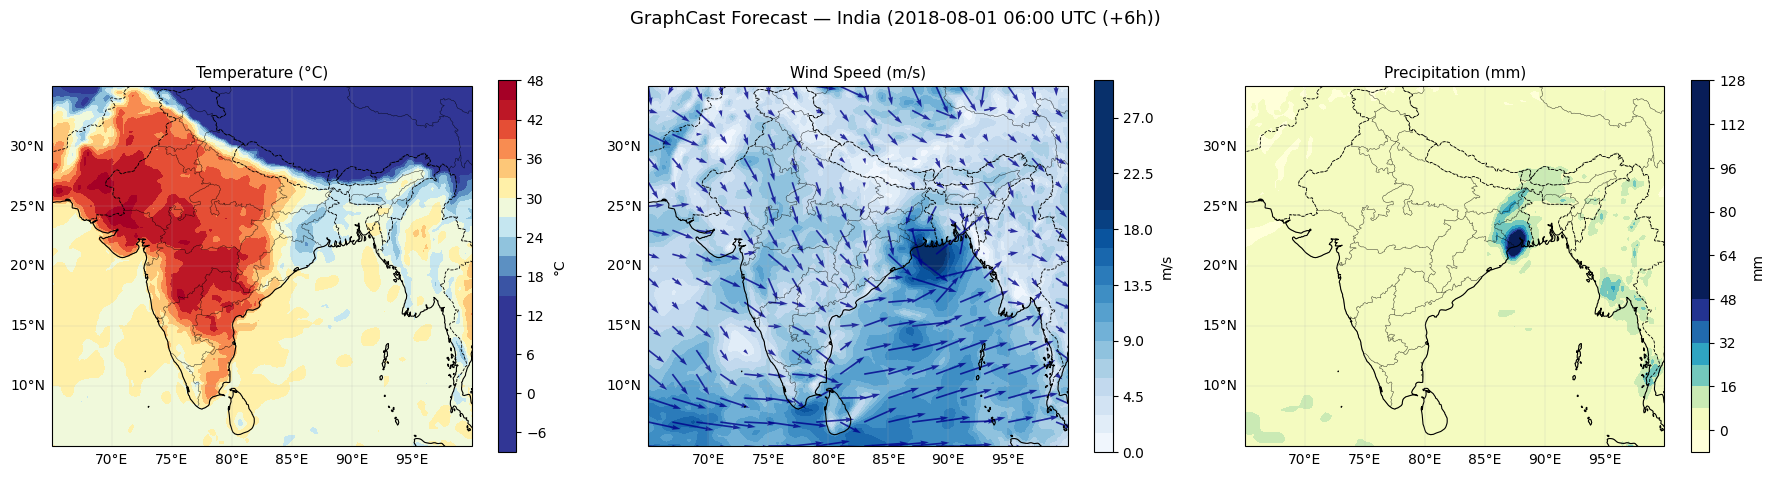

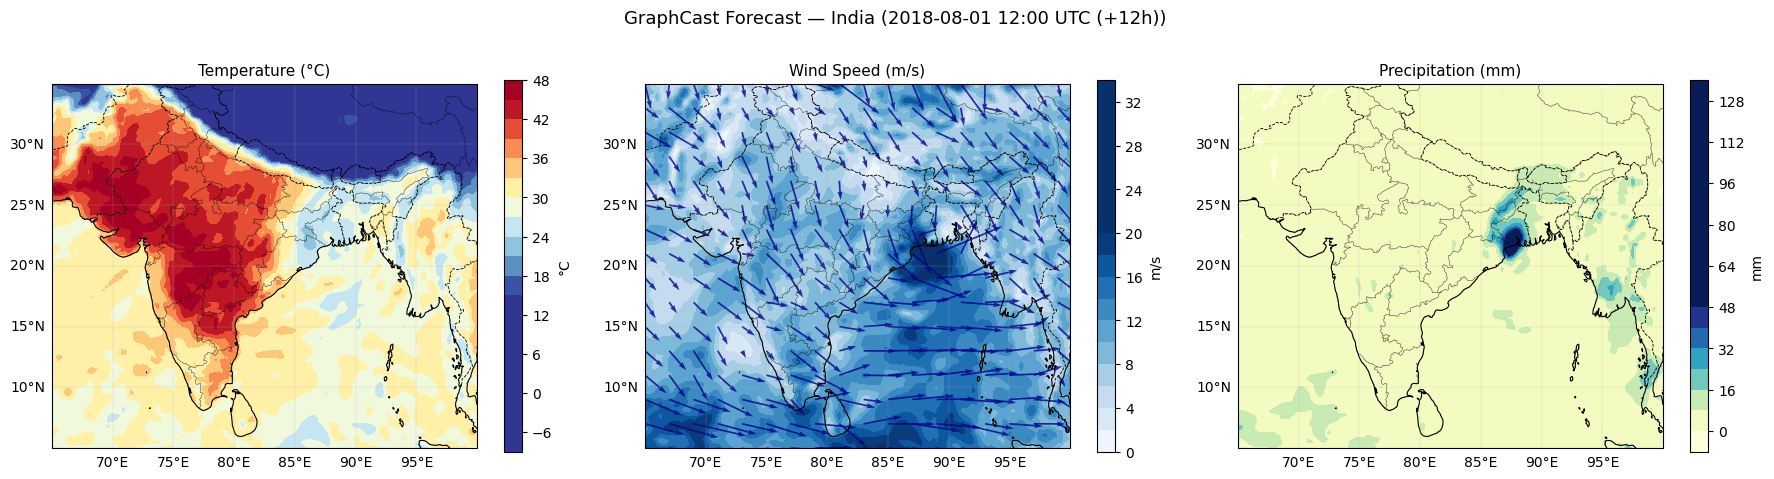

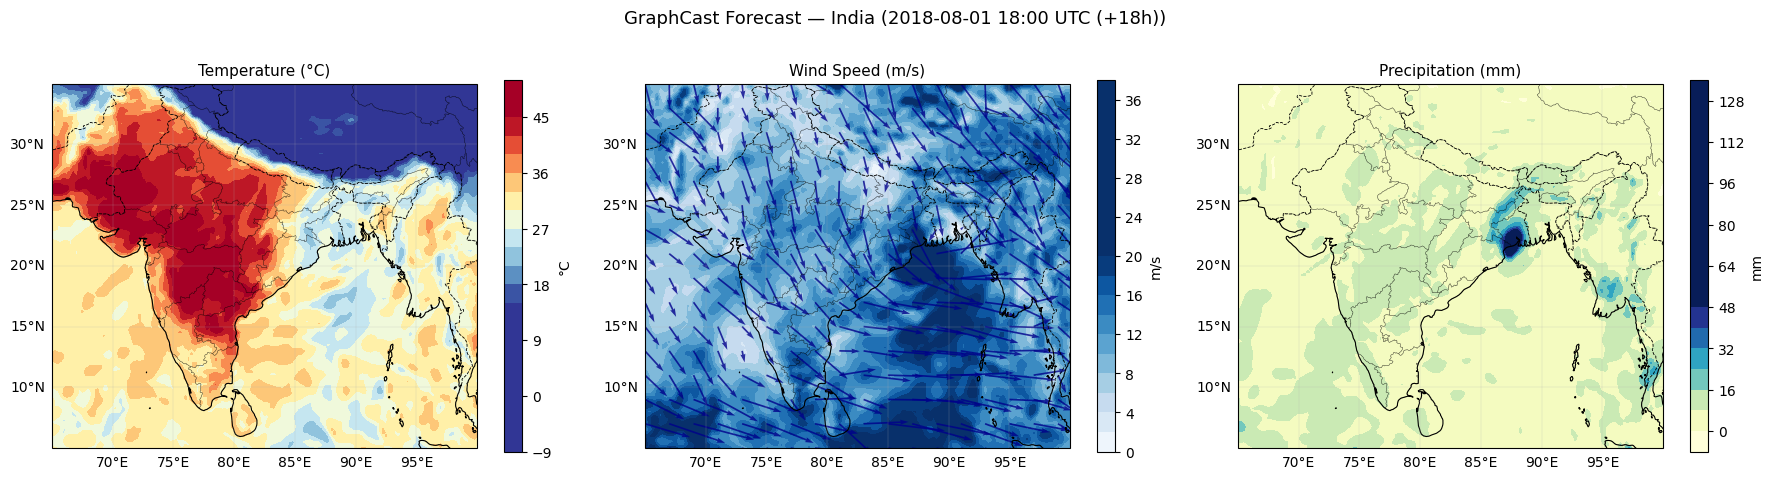

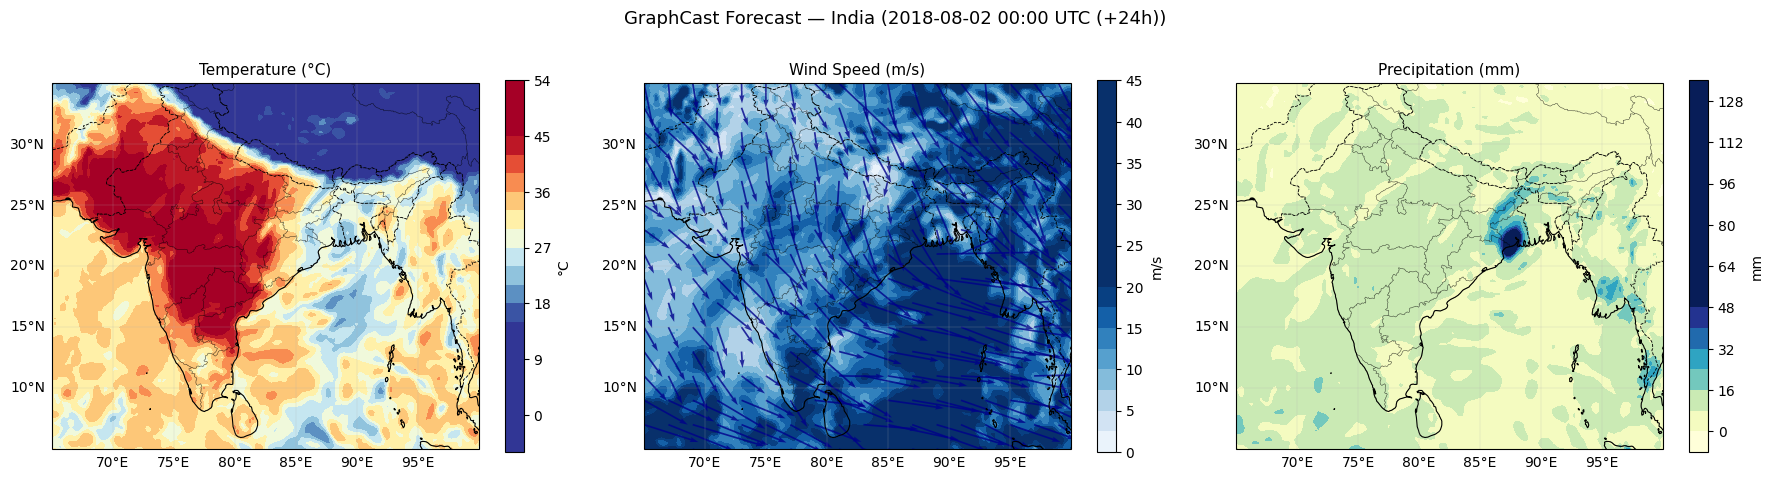

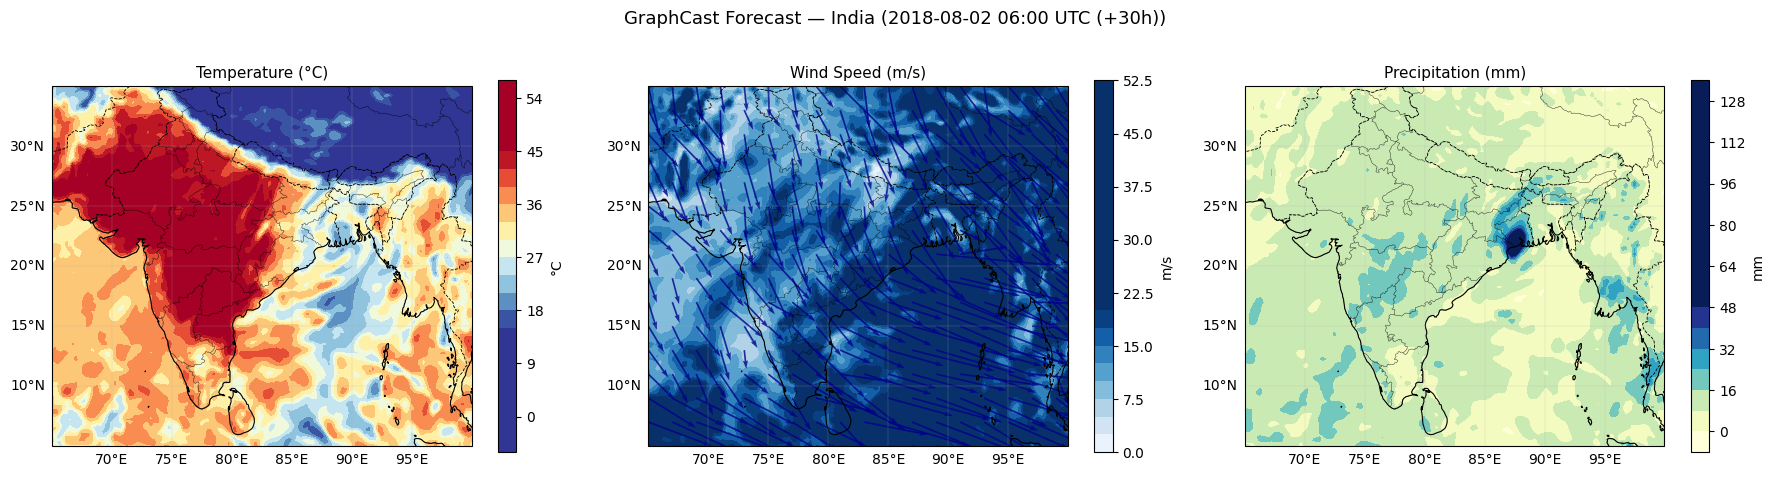

In [27]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd

has_precip = "total_precipitation_6hr" in india.data_vars or "total_precipitation" in india.data_vars
if has_precip:
    precip_key = "total_precipitation_6hr" if "total_precipitation_6hr" in india.data_vars else "total_precipitation"
    precip = india[precip_key] * 1000
try:
    base_time = pd.Timestamp(example_batch.coords["datetime"].values[0, 0])
except:
    base_time = pd.Timestamp("1970-01-01")
def get_step_label(i):
    try:
        delta = predictions.coords["time"].values[i]
        hours = int(delta / np.timedelta64(1, 'h'))
        forecast_time = base_time + pd.Timedelta(hours=hours)
        return forecast_time.strftime("%Y-%m-%d %H:%M UTC") + f" (+{hours}h)"
    except Exception as e:
        return f"Step {i+1}"

def base_map(ax, title):
    ax.set_extent([65, 100, 5, 35], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, linestyle="--")
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    ax.set_title(title, fontsize=11)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = gl.right_labels = False

ws_max = float(wind_speed.max())
n_steps = temp.sizes["time"]
ncols = 3 if has_precip else 2
for i in range(n_steps):
    fig, axes = plt.subplots(
        1, ncols, figsize=(6 * ncols, 5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    # Temperature
    base_map(axes[0], "Temperature (°C)")
    cf1 = axes[0].contourf(
        india.lon, india.lat,
        temp.isel(time=i, batch=0),
        levels=20, cmap="RdYlBu_r",
        vmin=15, vmax=45,          # realistic India range
        transform=ccrs.PlateCarree()
    )
    plt.colorbar(cf1, ax=axes[0], label="°C", shrink=0.85)

    # Wind
    base_map(axes[1], "Wind Speed (m/s)")
    cf2 = axes[1].contourf(
        india.lon, india.lat,
        wind_speed.isel(time=i, batch=0),
        levels=20, cmap="Blues",
        vmin=0, vmax=20,           # cap at 20 m/s for clarity
        transform=ccrs.PlateCarree()
    )
    plt.colorbar(cf2, ax=axes[1], label="m/s", shrink=0.85)
    step = 8                       # sparser arrows
    axes[1].quiver(
        india.lon.values[::step], india.lat.values[::step],
        u_wind.isel(time=i, batch=0).values[::step, ::step],
        v_wind.isel(time=i, batch=0).values[::step, ::step],
        transform=ccrs.PlateCarree(),
        scale=150, width=0.004, color="darkblue", alpha=0.8
    )

    # Precipitation
    if has_precip:
        base_map(axes[2], "Precipitation (mm)")
        cf3 = axes[2].contourf(
            india.lon, india.lat,
            precip.isel(time=i, batch=0),
            levels=20, cmap="YlGnBu",
            vmin=0, vmax=50,       # cap at 50mm per 6h
            transform=ccrs.PlateCarree()
        )
        plt.colorbar(cf3, ax=axes[2], label="mm", shrink=0.85)

    fig.suptitle(f"GraphCast Forecast — India ({get_step_label(i)})", fontsize=13)
    plt.tight_layout()
    plt.savefig(f'india_forecast_step_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()